# Data Exploration

In [8]:
import os, pathlib
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
import seaborn as sns
import sys
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pyarrow.dataset as ds

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.cleaning import *


load_dotenv()
RAW = pathlib.Path(os.getenv('DATA_DIR_RAW', '../data/raw'))
RAW.mkdir(parents=True, exist_ok=True)


PROC = pathlib.Path(os.getenv('DATA_DIR_PROC', '../data/processed'))
PROC.mkdir(parents=True, exist_ok=True)
# Define folder paths relative to this notebook


### First look

- We realize that there is no missing Data, 

In [9]:
# Helper display

df = pd.read_parquet(PROC / "citibike_cleaned.parquet")


def title(msg):
    print('\n' + '='*len(msg))
    print(msg)
    print('='*len(msg))

title('df.info()')
df.info()
title('Head & Tail')
display(df.head(3))
display(df.tail(3))
title('Missingness counts')
df.isna().sum()


df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1198422 entries, 0 to 1198421
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   name       1198422 non-null  object        
 1   bikes      1198422 non-null  int32         
 2   free       1198422 non-null  int32         
 3   timestamp  1198422 non-null  datetime64[us]
 4   date       1198422 non-null  object        
dtypes: datetime64[us](1), int32(2), object(2)
memory usage: 36.6+ MB

Head & Tail


,name,bikes,free,timestamp,date
0,1 Ave & E 110 St,0,0,2024-11-01 15:13:29,2024-11-01
1,1 Ave & E 110 St,0,25,2024-11-04 03:39:33,2024-11-04
2,1 Ave & E 110 St,12,13,2024-11-04 23:45:58,2024-11-04


,name,bikes,free,timestamp,date
1198419,York St & Marin Blvd,9,8,2025-07-30 22:24:02,2025-07-30
1198420,York St & Marin Blvd,8,9,2025-07-31 00:00:00,2025-07-31
1198421,York St & Marin Blvd,7,10,2025-07-31 22:54:01,2025-07-31



Missingness counts


name         0
bikes        0
free         0
timestamp    0
date         0
dtype: int64

### Distributions 

Does not provide much information, just worth investigating if those high numbers of bike are feasable, (is there really a stations with 120 spots)

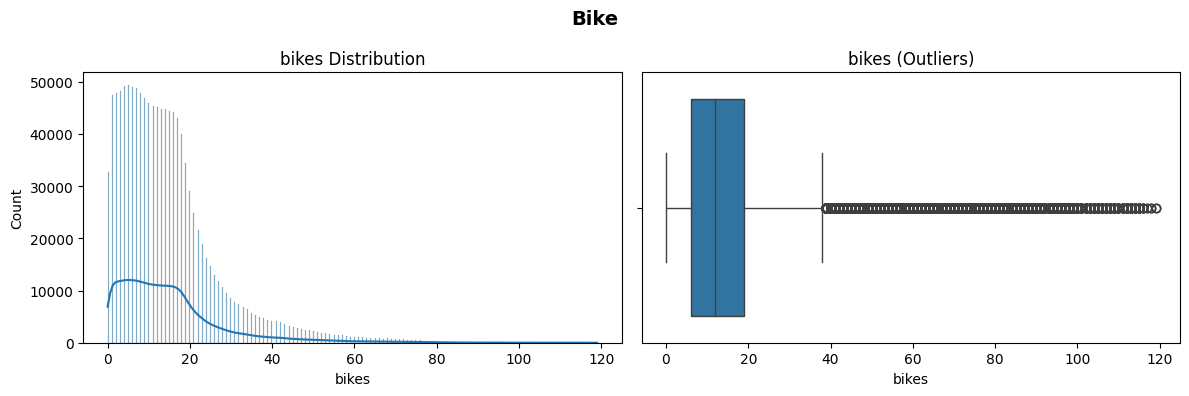

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bikes'], kde=True, ax=axes[0])
axes[0].set_title('bikes Distribution')
sns.boxplot(x='bikes', data=df, ax=axes[1])
axes[1].set_title('bikes (Outliers)')
plt.suptitle('Bike', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()



### Relationships
We see that where there are a lot of "outliers" on the bikes graph, there are none on the free spots, it give me the idea to feature engineer a column Free + bikes, to make sure the value is constant in every station

2263


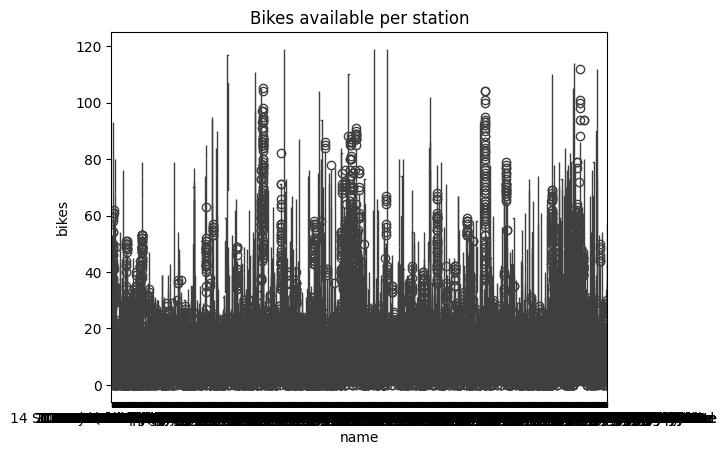

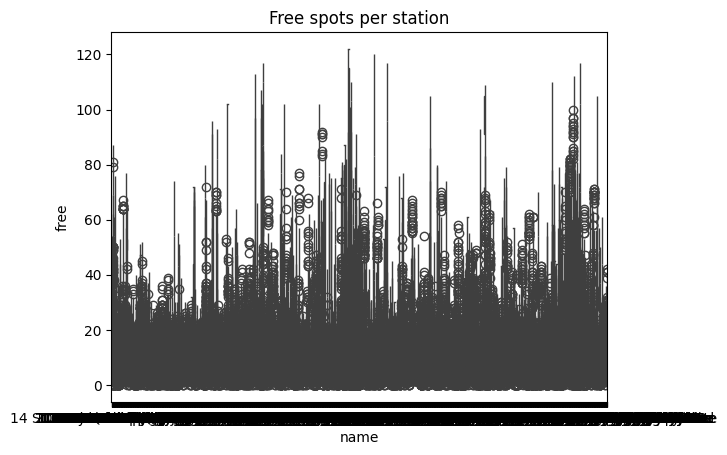

In [19]:
num_unique = df["name"].nunique()

print(num_unique)

sns.boxplot(data=df, x='name', y='bikes')
plt.title('Bikes available per station')
plt.show()

sns.boxplot(data=df, x='name', y='free')
plt.title('Free spots per station')
plt.show()